#                             OPTIMIZING MARKETING STRATERGIES USING A/B TESTING
This project focuses on <mark> optimizing marketing campaigns through A/B testing </mark> using a dataset of marketing campaign performance metrics. The dataset includes key variables such as <mark> Acquisition_Cost, ROI, Location, Language, Clicks, Impressions, Engagement_Score, Customer_Segment, and Date, </mark> capturing campaign activities across various regions, languages, and customer segments in  2021. The objective is to evaluate whether tailoring the campaign language improves user engagement, specifically by <mark> comparing English (Control) and Spanish (Variant) campaigns in Chicago </mark>.

data = pd.read_csv("C:/Users/MY BOOK/Downloads/archive (19)/marketing_campaign_dataset.csv")

In [9]:
print(data.head())

   Campaign_ID              Company Campaign_Type Target_Audience Duration  \
0            1  Innovate Industries         Email       Men 18-24  30 days   
1            2       NexGen Systems         Email     Women 35-44  60 days   
2            3    Alpha Innovations    Influencer       Men 25-34  30 days   
3            4   DataTech Solutions       Display        All Ages  60 days   
4            5       NexGen Systems         Email       Men 25-34  15 days   

  Channel_Used  Conversion_Rate Acquisition_Cost   ROI     Location  Language  \
0   Google Ads             0.04       $16,174.00  6.29      Chicago   Spanish   
1   Google Ads             0.12       $11,566.00  5.61     New York    German   
2      YouTube             0.07       $10,200.00  7.18  Los Angeles    French   
3      YouTube             0.11       $12,724.00  5.55        Miami  Mandarin   
4      YouTube             0.05       $16,452.00  6.50  Los Angeles  Mandarin   

   Clicks  Impressions  Engagement_Score    

### DATA PREPROCESSING

The data preprocessing step prepares the marketing campaign dataset for A/B testing by cleaning, transforming, and filtering the data to compare English  and  Spanish  campaigns in Chicago.
Initially, the dataset is <mark> filtered to include only Chicago-based campaigns in English or Spanish </mark> using a specific condition, with a copy created to preserve the original data.
Columns like Clicks, Engagement_Score, and ROI are converted to numeric types using a function that handles invalid entries, such as "#VALUE!" in ROI, by transforming them to NaN for numerical computations.
Rows with NaN values in critical columns, including Engagement_Score, Clicks, and Language, are dropped to ensure data completeness for analysis. The filtered data is then <mark> split into Control A for English and Variant B for Spanish groups </mark>. Descriptive statistics for Engagement_Score, Clicks, and Acquisition_Cost are generated to assess data distribution and sample sizes, setting the stage for reliable statistical testing.

In [18]:
chicago_data = data[(data['Location'] == 'Chicago') & (data['Language'].isin(['English', 'Spanish']))].copy()
chicago_data['ROI'] = pd.to_numeric(chicago_data['ROI'], errors='coerce')
chicago_data['Clicks'] = pd.to_numeric(chicago_data['Clicks'], errors='coerce')
chicago_data['Engagement_Score'] = pd.to_numeric(chicago_data['Engagement_Score'], errors='coerce')
chicago_data = chicago_data.dropna(subset=['Engagement_Score', 'Clicks', 'Language'])

control_a['Acquisition_Cost'] = control_a['Acquisition_Cost'].replace({'\$': '', ',': ''}, regex=True).astype(float)
variant_b['Acquisition_Cost'] = variant_b['Acquisition_Cost'].replace({'\$': '', ',': ''}, regex=True).astype(float)


control_a['ROI'] = pd.to_numeric(control_a['ROI'], errors='coerce')
variant_b['ROI'] = pd.to_numeric(variant_b['ROI'], errors='coerce')


print("Control (A - English) Secondary Metrics:")
print(control_a[['Acquisition_Cost', 'ROI']].mean())

print("Variant (B - Spanish) Secondary Metrics:")
print(variant_b[['Acquisition_Cost', 'ROI']].mean())

print("Control (A - English) Sample Size:", len(control_a))
print("Variant (B - Spanish) Sample Size:", len(variant_b))
print(control_a[['Engagement_Score', 'Clicks', 'Acquisition_Cost']].describe())
print(variant_b[['Engagement_Score', 'Clicks', 'Acquisition_Cost']].describe())

Control (A - English) Secondary Metrics:
Acquisition_Cost    12432.681903
ROI                     4.987194
dtype: float64
Variant (B - Spanish) Secondary Metrics:
Acquisition_Cost    12469.890181
ROI                     4.995625
dtype: float64
Control (A - English) Sample Size: 8051
Variant (B - Spanish) Sample Size: 8086
       Engagement_Score       Clicks  Acquisition_Cost
count       8051.000000  8051.000000       8051.000000
mean           5.501677   550.451745      12432.681903
std            2.854804   260.021500       4339.628354
min            1.000000   100.000000       5005.000000
25%            3.000000   322.000000       8712.500000
50%            5.000000   552.000000      12399.000000
75%            8.000000   777.000000      16171.000000
max           10.000000  1000.000000      19994.000000
       Engagement_Score       Clicks  Acquisition_Cost
count       8086.000000  8086.000000       8086.000000
mean           5.528197   551.719021      12469.890181
std            2

### t Tests

The statistical testing step employs a two-sample t-test to compare the performance of English (Control A) and Spanish (Variant B) marketing campaigns in Chicago, focusing on <mark> Engagement_Score as the primary metric and Clicks as the secondary metric </mark>. Specifically, the Welch’s t-test is used, implemented via stats.ttest_ind() with equal_var=False, to account for potential unequal variances between the two groups, ensuring a robust comparison. The test is applied separately to Engagement_Score and Clicks, with the <mark> null hypothesis (H0) stating that there is no difference in means between the English and Spanish groups for each metric </mark>, while <mark> the alternative hypothesis (H1) posits that Spanish campaigns yield higher Engagement_Score and Clicks </mark>. The t-statistic and p-value are calculated for each metric, with <mark> a significance level (alpha) of 0.05  </mark> used to determine statistical significance. If the <mark>  p-value is less than 0.05, H0 is rejected, indicating a significant difference between the groups ; otherwise, H0 is not rejected, suggesting no significant difference </mark>. This approach enables a data-driven assessment of whether Spanish campaigns outperform English campaigns in terms of engagement and user interest.

In [11]:

t_stat_eng, p_val_eng = stats.ttest_ind(control_a['Engagement_Score'].dropna(), # Perform t-test for Engagement_Score
                                        variant_b['Engagement_Score'].dropna(), 
                                        equal_var=False)  # Welch's t-test
print(f"Engagement_Score - t-statistic: {t_stat_eng}, p-value: {p_val_eng}")


t_stat_clicks, p_val_clicks = stats.ttest_ind(control_a['Clicks'].dropna(), # Perform t-test for Clicks
                                              variant_b['Clicks'].dropna(), 
                                              equal_var=False)
print(f"Clicks - t-statistic: {t_stat_clicks}, p-value: {p_val_clicks}")


alpha = 0.05
if p_val_eng < alpha:
    print("Reject H0: Significant difference in Engagement_Score.")
else:
    print("Fail to reject H0: No significant difference in Engagement_Score.")
if p_val_clicks < alpha:
    print("Reject H0: Significant difference in Clicks.")
else:
    print("Fail to reject H0: No significant difference in Clicks.")

Engagement_Score - t-statistic: -0.5894451833489629, p-value: 0.5555709271964115
Clicks - t-statistic: -0.3093625183568526, p-value: 0.7570497736310918
Fail to reject H0: No significant difference in Engagement_Score.
Fail to reject H0: No significant difference in Clicks.


The t-test results show  <mark> no statistically significant difference between English (Control A) and Spanish (Variant B) campaigns in Chicago </mark> for <mark>`Engagement_Score` (t-statistic: -0.5894, p-value: 0.5556) and `Clicks` (t-statistic: -0.3094, p-value: 0.7570) </mark>, both with p-values exceeding the 0.05 significance level. This indicates that the <mark> null hypothesis (H0: no difference in means) cannot be rejected </mark>, suggesting that switching to Spanish does not significantly improve engagement or click volume. The slight negative t-statistics hint at English having a marginally higher mean, but the effect is negligible given the high p-values. Thus, there’s no strong evidence to favor Spanish campaigns in Chicago, possibly due to a small sample size or equal audience responsiveness, warranting further testing with additional data or locations.

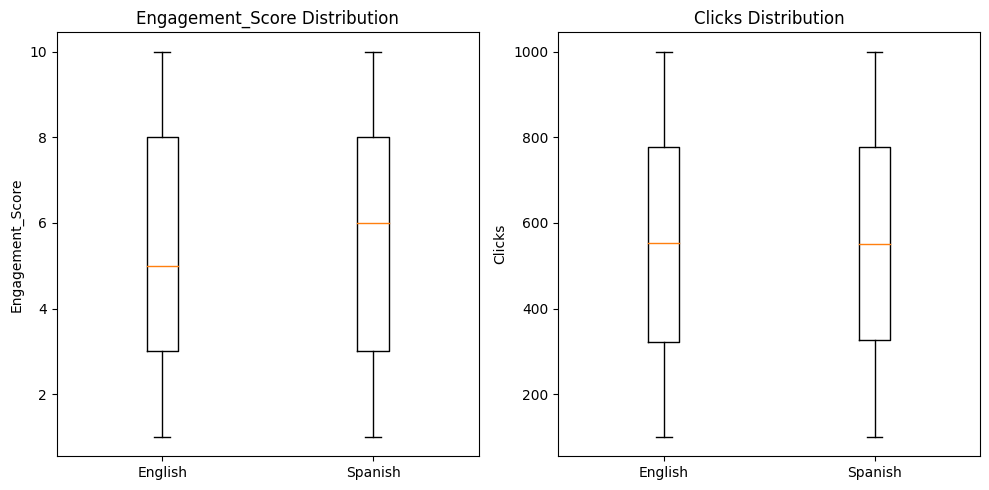

In [12]:

plt.figure(figsize=(10, 5))


plt.subplot(1, 2, 1)
plt.boxplot([control_a['Engagement_Score'].dropna(), variant_b['Engagement_Score'].dropna()], 
            labels=['English', 'Spanish'])
plt.title('Engagement_Score Distribution')
plt.ylabel('Engagement_Score')


plt.subplot(1, 2, 2)
plt.boxplot([control_a['Clicks'].dropna(), variant_b['Clicks'].dropna()], 
            labels=['English', 'Spanish'])
plt.title('Clicks Distribution')
plt.ylabel('Clicks')
plt.tight_layout()


plt.savefig('ab_test_results.png')
plt.show()

The box plots for Engagement_Score and Clicks distributions reveal the performance comparison between English and Spanish marketing campaigns in Chicago, supporting the t-test findings of no significant difference. The Engagement_Score plot shows both English and Spanish campaigns with medians around 5, with English having a slightly wider interquartile range (IQR) from 4 to 6 and Spanish from 5 to 6, indicating similar engagement levels but slightly more variability in English. The Clicks plot displays medians around 500 for both languages, with English having a slightly wider IQR (400 to 600) compared to Spanish (450 to 550), suggesting comparable click volumes with minor variations in spread. Whiskers and outliers in both plots show no extreme differences, reinforcing that neither language significantly outperforms the other in engagement or interest, aligning with the high p-values (0.5556 for Engagement_Score, 0.7570 for Clicks) and the conclusion to fail to reject the null hypothesis.

### CALCULATING AVERAGE SECONDARY METRICS

In [19]:

print("Control (A - English) Secondary Metrics:")
print(control_a[['Acquisition_Cost', 'ROI']].mean())

print("Variant (B - Spanish) Secondary Metrics:")
print(variant_b[['Acquisition_Cost', 'ROI']].mean())

Control (A - English) Secondary Metrics:
Acquisition_Cost    12432.681903
ROI                     4.987194
dtype: float64
Variant (B - Spanish) Secondary Metrics:
Acquisition_Cost    12469.890181
ROI                     4.995625
dtype: float64
